# Laboratorio 7 — Spark MLlib
## 05. Pipeline de regresión lineal

Se busca responder: **¿qué tan bien puede estimarse el salario mensual de una persona asalariada con edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio?**

- Datos: `data/processed/personas_2025.parquet` (población analítica de la sección 1).
- **Entrenamiento:** 2025 I, II y III. **Validación:** 2025 IV. El primer trimestre de 2026 **no se toca** aquí: se reserva para la evaluación final.
- Todos los componentes del pipeline (indexadores, codificador, escalado y regresión) se ajustan solo con entrenamiento. MAE, RMSE y R² se calculan con **todos** los registros de cada conjunto, sin ponderar.
- El objetivo se mantiene en quetzales, sin transformar ni recortar valores extremos.
- Las asociaciones no son causales, y las estimaciones describen los registros analizados, no a la población guatemalteca.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src import config, modelado, regresion_lineal

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

config.FIGURES.mkdir(parents=True, exist_ok=True)
config.TABLES.mkdir(parents=True, exist_ok=True)
config.MODELOS.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_05_regresion_lineal")
spark.sparkContext.setLogLevel("ERROR")

entrenamiento, validacion = modelado.cargar_conjuntos(spark)
entrenamiento, validacion = entrenamiento.persist(), validacion.persist()

tamanos = pd.DataFrame({
    "conjunto": ["entrenamiento (2025 I-III)", "validación (2025 IV)"],
    "registros": [entrenamiento.count(), validacion.count()],
})
tamanos

,conjunto,registros
0,entrenamiento (2025 I-III),40361
1,validación (2025 IV),12664


**Lectura.** La validación es un trimestre completo posterior a los de entrenamiento, no una muestra al azar. Así se imita el uso real del modelo (estimar un período que no se vio al ajustar) y se evita mezclar en validación a las mismas personas observadas en trimestres de entrenamiento con un sorteo aleatorio de filas.

## 1. Modelo de referencia

Antes de ajustar la regresión se necesita un punto de comparación: un modelo que **no usa ningún predictor** y estima para todos el salario **medio de entrenamiento**. Un modelo con predictores solo aporta si supera este valor. También se reporta la mediana de entrenamiento, que es menos sensible a los salarios altos.

El R² de validación de la referencia queda cerca de 0 (puede ser levemente negativo): predecir siempre un mismo valor no explica variación alguna.

In [2]:
media_ref = modelado.referencia(entrenamiento, "media")
mediana_ref = modelado.referencia(entrenamiento, "mediana")

ref_media = modelado.metricas(modelado.predecir_referencia(validacion, media_ref))
ref_mediana = modelado.metricas(modelado.predecir_referencia(validacion, mediana_ref))

tabla_ref = modelado.tabla_metricas({
    f"referencia: media de entrenamiento (Q{media_ref:,.0f})": ref_media,
    f"referencia: mediana de entrenamiento (Q{mediana_ref:,.0f})": ref_mediana,
})
tabla_ref

,modelo,mae,rmse,r2,n
0,"referencia: media de entrenamiento (Q3,383)","1,672.503","2,889.571",-0.003,"12,664.000"
1,"referencia: mediana de entrenamiento (Q3,000)","1,670.390","2,936.004",-0.036,"12,664.000"


## 2. Pipeline de regresión lineal

El pipeline tiene cuatro componentes:

| Etapa | Componente | Variables |
|---|---|---|
| a | `StringIndexer` + `OneHotEncoder` | nivel educativo, categoría ocupacional, dominio |
| b | `VectorAssembler` | edad, antigüedad, horas semanales + categóricas codificadas |
| c | Estandarización interna de `LinearRegression` (`standardization=True`) | todos los predictores |
| d | `LinearRegression` | `salario_mensual` |

Decisiones:

- Los indexadores usan `handleInvalid="keep"`: si validación o prueba traen una categoría que no existía en entrenamiento, recibe una columna propia (siempre en cero al ajustar) en lugar de romper el pipeline. `DESCONOCIDO` es una categoría más.
- Se usa la estandarización interna de `LinearRegression`, no `StandardScaler`, porque el enunciado pide uno solo de los dos mecanismos. Los coeficientes se reportan en las unidades originales de cada predictor.
- Son exactamente seis predictores; no entran identificadores, `FACTOR` ni otros ingresos.

In [3]:
etapas = regresion_lineal.pipeline_lineal(0.1, 0.0).getStages()
pd.DataFrame({
    "etapa": range(1, len(etapas) + 1),
    "componente": [type(e).__name__ for e in etapas],
    "entrada": [e.getInputCols() if e.hasParam("inputCols") and e.isSet("inputCols")
                else (e.getInputCol() if e.hasParam("inputCol") and e.isSet("inputCol") else "features")
                for e in etapas],
})

,etapa,componente,entrada
0,1,StringIndexer,nivel_educativo
1,2,StringIndexer,categoria_ocupacional
2,3,StringIndexer,dominio
3,4,OneHotEncoder,"[nivel_educativo_idx, categoria_ocupacional_id..."
4,5,VectorAssembler,"[edad, antiguedad, horas_semanales, nivel_educ..."
5,6,LinearRegression,features


## 3. Regularización: configuraciones probadas

`LinearRegression` minimiza el error cuadrático más una penalización: `regParam` fija su intensidad y `elasticNetParam` reparte la penalización entre L2 (Ridge, 0) y L1 (Lasso, 1). Ridge encoge los coeficientes; Lasso puede llevar algunos exactamente a cero.

| Configuración | `regParam` | `elasticNetParam` |
|---|---|---|
| `sin_regularizacion` | 0.0 | 0.0 |
| `ridge_0.1` | 0.1 | 0.0 |
| `ridge_1.0` | 1.0 | 0.0 |
| `lasso_0.1` | 0.1 | 1.0 |
| `elasticnet_0.1_0.5` | 0.1 | 0.5 |

**Criterio de selección:** menor **RMSE de validación**. Cada configuración se ajusta solo con entrenamiento.

In [4]:
tabla, modelos = regresion_lineal.evaluar_configuraciones(entrenamiento, validacion)
mejor = regresion_lineal.elegir_mejor(tabla)

comparacion = tabla.sort_values("rmse_validacion", ignore_index=True)
comparacion.insert(0, "seleccionada", np.where(comparacion["configuracion"] == mejor, "sí", ""))
comparacion

,seleccionada,configuracion,regParam,elasticNetParam,mae_entrenamiento,rmse_entrenamiento,r2_entrenamiento,mae_validacion,rmse_validacion,r2_validacion
0,sí,sin_regularizacion,0.000,0.000,"1,237.790","2,245.293",0.403,"1,210.137","2,186.420",0.426
1,,ridge_0.1,0.100,0.000,"1,237.787","2,245.293",0.403,"1,210.133","2,186.421",0.426
2,,elasticnet_0.1_0.5,0.100,0.500,"1,237.766","2,245.293",0.403,"1,210.107","2,186.425",0.426
3,,lasso_0.1,0.100,1.000,"1,237.747","2,245.293",0.403,"1,210.085","2,186.428",0.426
4,,ridge_1.0,1.000,0.000,"1,237.752","2,245.293",0.403,"1,210.090","2,186.432",0.426


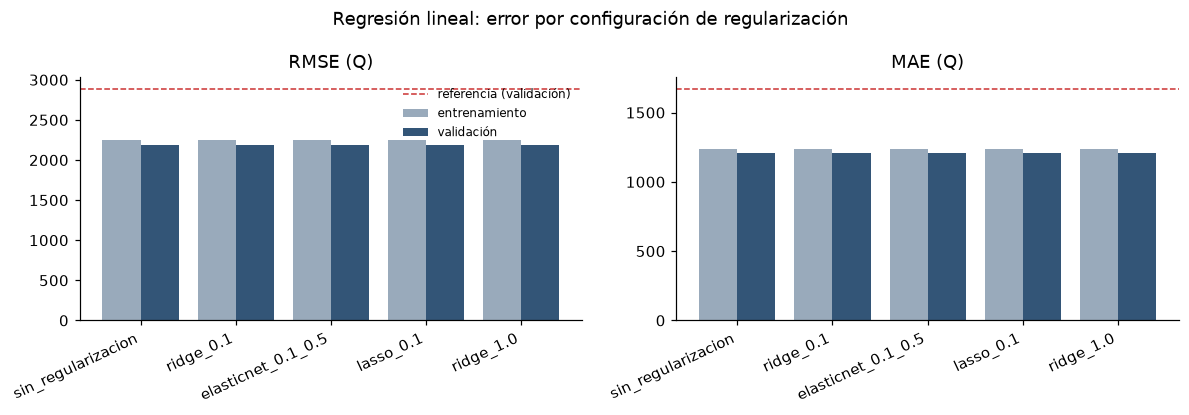

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))
orden = comparacion["configuracion"].tolist()
pos = np.arange(len(orden))
for eje, metrica, titulo in zip(ejes, ["rmse", "mae"], ["RMSE (Q)", "MAE (Q)"]):
    eje.bar(pos - 0.2, comparacion[f"{metrica}_entrenamiento"], width=0.4, label="entrenamiento", color="#9ab")
    eje.bar(pos + 0.2, comparacion[f"{metrica}_validacion"], width=0.4, label="validación", color="#357")
    eje.axhline(ref_media[metrica], color="#c33", ls="--", lw=1, label="referencia (validación)")
    eje.set_xticks(pos, orden, rotation=25, ha="right")
    eje.set_title(titulo)
ejes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Regresión lineal: error por configuración de regularización")
fig.tight_layout()
fig.savefig(config.FIGURES / "05_error_por_configuracion.png", bbox_inches="tight")
plt.show()

In [6]:
fila = comparacion.set_index("configuracion")
m = fila.loc[mejor]
mejora_rmse = 100 * (1 - m["rmse_validacion"] / ref_media["rmse"])
mejora_mae = 100 * (1 - m["mae_validacion"] / ref_media["mae"])
rango_rmse = comparacion["rmse_validacion"].max() - comparacion["rmse_validacion"].min()
brecha = m["rmse_validacion"] / m["rmse_entrenamiento"] - 1
efecto_reg = ("la regularización cambia poco el resultado, porque hay pocos predictores y muchos registros"
              if rango_rmse < 0.02 * m["rmse_validacion"] else "la regularización sí modifica el resultado")
sobreajuste = "no hay señal de sobreajuste" if abs(brecha) < 0.1 else "hay una brecha que conviene vigilar"

display(Markdown(f"""
**Lectura.**

- La configuración con menor RMSE de validación es **`{mejor}`** (`regParam = {m['regParam']}`, `elasticNetParam = {m['elasticNetParam']}`): RMSE **Q{m['rmse_validacion']:,.0f}**, MAE **Q{m['mae_validacion']:,.0f}** y R² **{m['r2_validacion']:.3f}**.
- Frente a la referencia (siempre el salario medio de entrenamiento: RMSE Q{ref_media['rmse']:,.0f}, MAE Q{ref_media['mae']:,.0f}), el RMSE baja **{mejora_rmse:.1f} %** y el MAE **{mejora_mae:.1f} %**. El R² indica que los seis predictores explican **{100 * m['r2_validacion']:.1f} %** de la variación del salario en validación.
- Entre las cinco configuraciones el RMSE de validación varía solo Q{rango_rmse:,.3f}: {efecto_reg}.
- El RMSE de validación es {100 * abs(brecha):.1f} % {'mayor' if brecha >= 0 else 'menor'} que el de entrenamiento: {sobreajuste}. Validación es un trimestre distinto, así que la comparación también refleja cambios de un trimestre a otro.
- El RMSE es mayor que el MAE porque penaliza más los errores grandes; con salarios muy asimétricos, unos pocos salarios altos mal estimados elevan el RMSE.
"""))


**Lectura.**

- La configuración con menor RMSE de validación es **`sin_regularizacion`** (`regParam = 0.0`, `elasticNetParam = 0.0`): RMSE **Q2,186**, MAE **Q1,210** y R² **0.426**.
- Frente a la referencia (siempre el salario medio de entrenamiento: RMSE Q2,890, MAE Q1,673), el RMSE baja **24.3 %** y el MAE **27.6 %**. El R² indica que los seis predictores explican **42.6 %** de la variación del salario en validación.
- Entre las cinco configuraciones el RMSE de validación varía solo Q0.013: la regularización cambia poco el resultado, porque hay pocos predictores y muchos registros.
- El RMSE de validación es 2.6 % menor que el de entrenamiento: no hay señal de sobreajuste. Validación es un trimestre distinto, así que la comparación también refleja cambios de un trimestre a otro.
- El RMSE es mayor que el MAE porque penaliza más los errores grandes; con salarios muy asimétricos, unos pocos salarios altos mal estimados elevan el RMSE.


## 4. Coeficientes del mejor modelo

Los coeficientes están en quetzales por unidad del predictor (años, horas) o por pertenecer a una categoría. Las variables categóricas no tienen nivel de referencia: cada categoría observada tiene su columna, por lo que el intercepto y los coeficientes de una misma variable no se leen por separado, sino **entre categorías** (la diferencia entre dos coeficientes es la diferencia estimada entre ellas, con el resto igual). Son asociaciones, no efectos causales.

In [7]:
mejor_modelo = modelos[mejor]
coef = regresion_lineal.coeficientes(mejor_modelo)
coef

,variable,coeficiente
0,(intercepto),"1,775.504"
1,nivel_educativo=7,"8,702.197"
2,nivel_educativo=6,"6,863.059"
3,nivel_educativo=5,"1,776.886"
4,categoria_ocupacional=1,"1,424.310"
5,categoria_ocupacional=4,"-1,413.857"
6,nivel_educativo=0,"-1,250.902"
7,nivel_educativo=1,-966.575
8,nivel_educativo=2,-753.934
9,categoria_ocupacional=3,-607.768


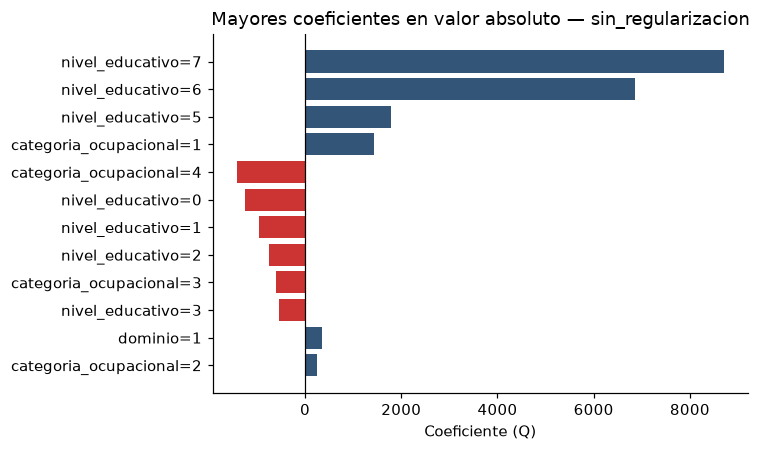

In [8]:
top = coef[coef["variable"] != "(intercepto)"].head(12).iloc[::-1]
fig, eje = plt.subplots(figsize=(7, 4.2))
eje.barh(top["variable"], top["coeficiente"], color=np.where(top["coeficiente"] >= 0, "#357", "#c33"))
eje.axvline(0, color="k", lw=0.8)
eje.set_xlabel("Coeficiente (Q)")
eje.set_title(f"Mayores coeficientes en valor absoluto — {mejor}")
fig.tight_layout()
fig.savefig(config.FIGURES / "05_coeficientes.png", bbox_inches="tight")
plt.show()

In [9]:
numericos = coef.set_index("variable").loc[config.NUMERICAS, "coeficiente"]
educ = coef[coef["variable"].str.startswith("nivel_educativo=") & ~coef["variable"].str.endswith("<no vista>")]
educ_max, educ_min = educ.loc[educ["coeficiente"].idxmax()], educ.loc[educ["coeficiente"].idxmin()]

display(Markdown(f"""
**Lectura.**

- Cada año adicional de edad se asocia con **Q{numericos['edad']:,.1f}** más de salario mensual, cada año de antigüedad con **Q{numericos['antiguedad']:,.1f}** y cada hora semanal habitual con **Q{numericos['horas_semanales']:,.1f}**, manteniendo el resto igual.
- Entre niveles educativos, el coeficiente más alto es `{educ_max['variable']}` (Q{educ_max['coeficiente']:,.0f}) y el más bajo `{educ_min['variable']}` (Q{educ_min['coeficiente']:,.0f}); la distancia entre ambos es Q{educ_max['coeficiente'] - educ_min['coeficiente']:,.0f}.
- El modelo es **lineal y aditivo**: supone que el efecto de cada variable es el mismo para todos los perfiles y no captura interacciones (por ejemplo, que la educación pese distinto según la categoría ocupacional). Esa limitación es lo que el Random Forest de la actividad siguiente puede o no mejorar.
"""))


**Lectura.**

- Cada año adicional de edad se asocia con **Q20.4** más de salario mensual, cada año de antigüedad con **Q23.4** y cada hora semanal habitual con **Q16.2**, manteniendo el resto igual.
- Entre niveles educativos, el coeficiente más alto es `nivel_educativo=7` (Q8,702) y el más bajo `nivel_educativo=0` (Q-1,251); la distancia entre ambos es Q9,953.
- El modelo es **lineal y aditivo**: supone que el efecto de cada variable es el mismo para todos los perfiles y no captura interacciones (por ejemplo, que la educación pese distinto según la categoría ocupacional). Esa limitación es lo que el Random Forest de la actividad siguiente puede o no mejorar.


## 5. Guardado del mejor modelo

Se guarda el pipeline ajustado con la configuración seleccionada en `results/modelos/regresion_lineal` (no se versiona) y las tablas en `results/tables/`. El primer trimestre de 2026 se reserva para la evaluación final. Para esa evaluación se reajustará la configuración elegida con los cuatro trimestres de 2025.

In [10]:
regresion_lineal.guardar_resultados(tabla, mejor, mejor_modelo, coef)
print(f"Modelo guardado en {config.MODELOS / 'regresion_lineal'}")
print("Tablas:", sorted(p.name for p in config.TABLES.glob("05_*.csv")))

Modelo guardado en C:\Users\anna2\Desktop\UVG\Data Science\Laboratorio-7-Introduccion-a-Spark\results\modelos\regresion_lineal
Tablas: ['05_coeficientes_regresion_lineal.csv', '05_metricas_regresion_lineal.csv']


## 6. Conclusión de la actividad

La regresión lineal regularizada, con los seis predictores del enunciado, se compara contra la referencia de la sección 1 usando el mismo conjunto de validación. Su desempeño queda acotado por la forma lineal y aditiva del modelo y por la cola de salarios altos, que se mantuvo sin recortar. Estas cifras son el punto de comparación del Random Forest (actividad 6) y de la evaluación final en 2026 (actividad 7).